In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/azharsaleem/real-estate-goldmine-dubai-uae-rental-market/dubai_properties.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/azharsaleem/real-estate-goldmine-dubai-uae-rental-market/dubai_properties.csv')
df.head()
df.columns

Index(['Address', 'Rent', 'Beds', 'Baths', 'Type', 'Area_in_sqft',
       'Rent_per_sqft', 'Rent_category', 'Frequency', 'Furnishing', 'Purpose',
       'Posted_date', 'Age_of_listing_in_days', 'Location', 'City', 'Latitude',
       'Longitude'],
      dtype='object')

In [4]:
print(df.isnull().sum())

Address                     0
Rent                        0
Beds                        0
Baths                       0
Type                        0
Area_in_sqft                0
Rent_per_sqft               0
Rent_category               0
Frequency                   0
Furnishing                  0
Purpose                     0
Posted_date                 0
Age_of_listing_in_days      0
Location                    0
City                        0
Latitude                  719
Longitude                 719
dtype: int64


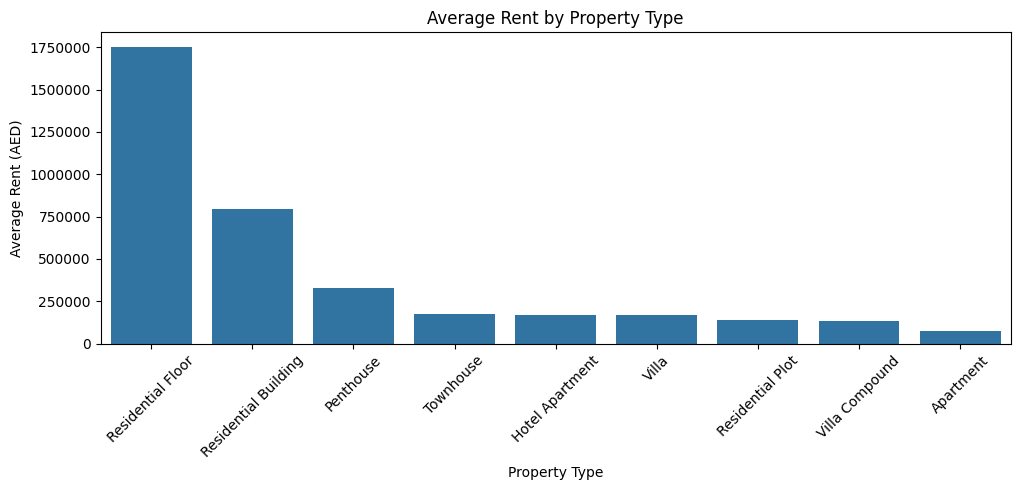

In [17]:
avg_type = df.groupby('Type')['Rent'].median().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=avg_type.index, y=avg_type.values)
plt.xticks(rotation=45)
plt.title("Average Rent by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Average Rent (AED)")
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='y')
plt.show()

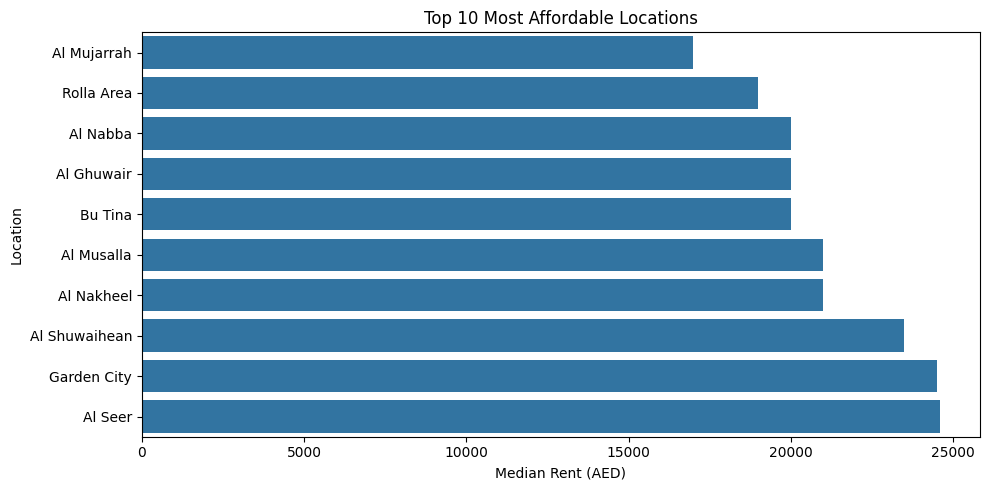

In [14]:
location_counts = df['Location'].value_counts()
valid_locations = location_counts[location_counts >= 20].index
filtered_df = df[df['Location'].isin(valid_locations)]
affordable = (filtered_df.groupby('Location')['Rent'].median().sort_values(ascending=True).head(10))
plt.figure(figsize=(10,5))
sns.barplot(x=affordable.values, y=affordable.index)
plt.title("Top 10 Most Affordable Locations")
plt.xlabel("Median Rent (AED)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

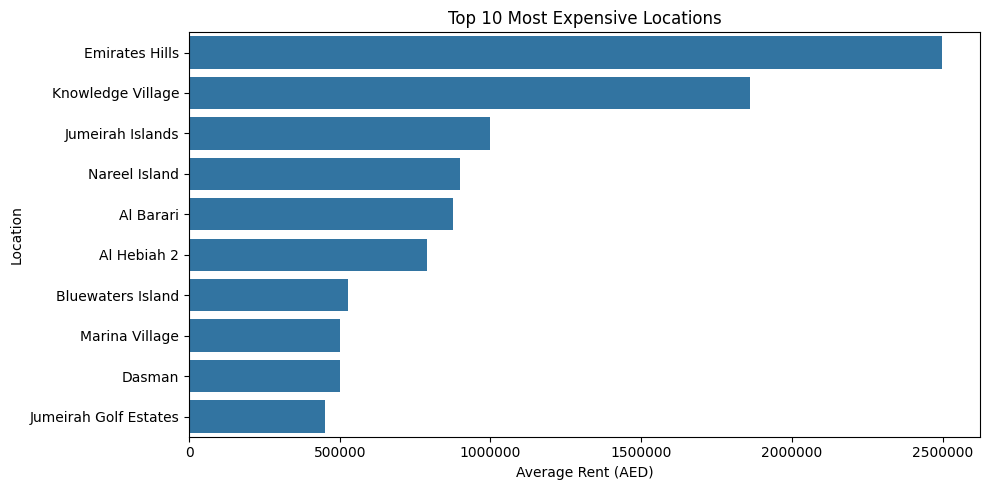

In [12]:
expensive = df.groupby('Location')['Rent'].median().sort_values(ascending=False).head(10)
#location of luxury properties
plt.figure(figsize=(10,5))
sns.barplot(x=expensive.values, y=expensive.index)
plt.title("Top 10 Most Expensive Locations") 
plt.xlabel("Average Rent (AED)")
plt.ylabel("Location")
plt.tight_layout()
plt.ticklabel_format(style='plain', axis='x')
plt.show()

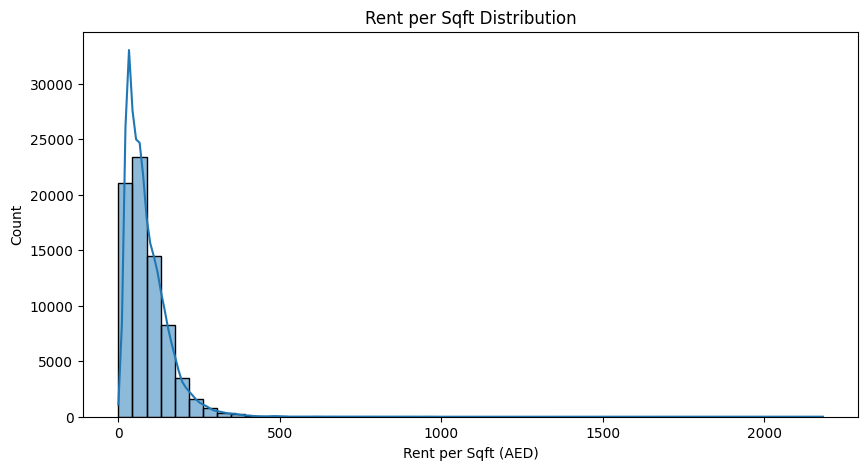

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['Rent_per_sqft'], bins=50, kde=True)
plt.title("Rent per Sqft Distribution")
plt.xlabel("Rent per Sqft (AED)")
plt.show()

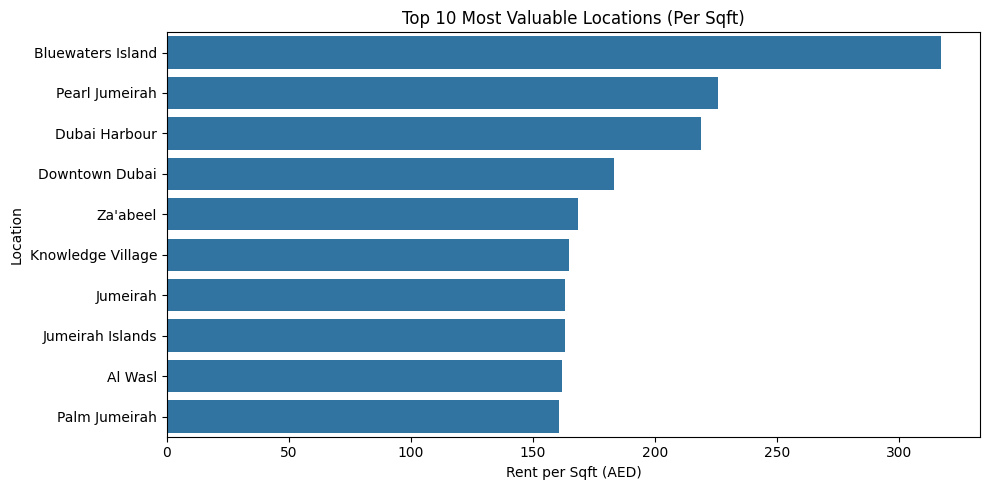

In [24]:
median_sqft = df.groupby('Location')['Rent_per_sqft'].median().sort_values(ascending=False).head(10)
#shows value of the land 
plt.figure(figsize=(10,5))
sns.barplot(x=median_sqft.values, y=median_sqft.index)
plt.title("Top 10 Most Valuable Locations (Per Sqft)")
plt.xlabel("Rent per Sqft (AED)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

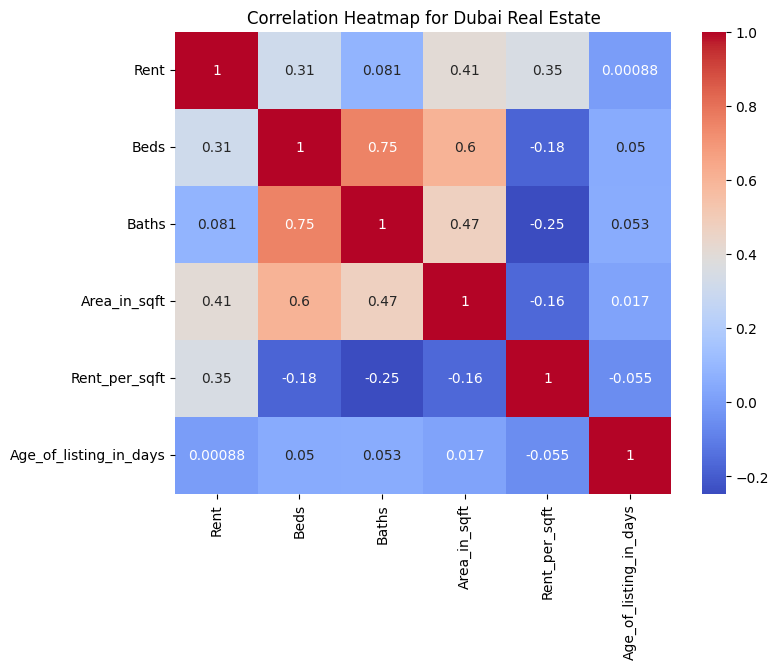

In [25]:
numeric_cols = ['Rent', 'Beds', 'Baths', 'Area_in_sqft', 'Rent_per_sqft', 'Age_of_listing_in_days']

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap for Dubai Real Estate")
plt.show()